In [1]:
from utils import *

In [2]:
from real_data_utils import *

Experimental data is loaded successfully.
Following table displays all Mouse-Date pairs.


,Unnamed: 0,Mouse,Date
0,0,CB279,121621
1,1,CB279,121421
2,2,CB279,122021
3,3,CB278,121521
4,4,CB278,121721
5,5,CB278,121921
6,6,CB295,040222
7,7,CB295,040622
8,8,CB295,033022
9,9,CB293,040222


In [3]:
import pandas as pd
import numpy as np
import os
import contextlib
from multiprocess import Pool # <-- The magic library that fixes the macOS/Jupyter bug
from tqdm.auto import tqdm
from IPython.display import display

# 1. Define the worker function
# NOTE: We modified this to accept a single tuple of arguments so it plays nicely with imap_unordered
def process_mouse_date_pair(args):
    mouse, date, q_values = args
    results = []
    try:
        # Fetch data from the global dictionary (multiprocess handles this perfectly)
        stim_0_trials = MDT_to_trials[(mouse, date, 0)]
        stim_1_trials = MDT_to_trials[(mouse, date, 1)]

        X_rasters = stim_0_trials + stim_1_trials
        y = np.array([0] * len(stim_0_trials) + [1] * len(stim_1_trials))

        # Suppress inner tqdm and print statements completely to keep your screen clean
        with open(os.devnull, 'w') as fnull:
            with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                for q in q_values:
                    score = tda_rhv(X_rasters, y, q=q)
                    if score is not None:
                        results.append({
                            'Mouse': mouse,
                            'Date': date,
                            'q': q,
                            'TDA Score': score
                        })
    except Exception as e:
        # Catch errors so one bad trial doesn't crash the whole 8-core pool
        return {'error': str(e), 'mouse': mouse, 'date': date}
        
    return results

# Guard block: Essential for safe multiprocessing on Mac/Windows
if __name__ == '__main__':
    # 2. Setup Parameters and Output Files
    q_values_list = np.arange(0,2.001,0.005,dtype=float)
    csv_filename = "q_values_results.csv"
    
    # Initialize an empty CSV with headers
    pd.DataFrame(columns=['Mouse', 'Date', 'q', 'TDA Score']).to_csv(csv_filename, index=False)
    
    results_list_2class = []
    
    print(f"Starting parallel processing on 8 CPUs. Saving live to: {csv_filename}")
    
    # Create a dedicated display handle so the dataframe updates smoothly below the progress bar
    df_display = display(pd.DataFrame(columns=['Mouse', 'Date', 'q', 'TDA Score']), display_id=True)
    
    # Package up our arguments for the worker function
    tasks = [(row['Mouse'], row['Date'], q_values_list) for index, row in pairs.iterrows()]
    
    # 3. Launch the Multiprocess Pool
    with Pool(processes=8) as pool:
        
        # imap_unordered yields a result the exact millisecond a CPU finishes it
        # tqdm wraps this to give you a live ETA and iterations/second
        for res in tqdm(pool.imap_unordered(process_mouse_date_pair, tasks), total=len(tasks), desc="Mouse-Date Pairs"):
            
            
            # Check if the result was successful (a list of dicts) and not an error dict
            if isinstance(res, list) and len(res) > 0:
                
                # 1. Append to our live memory list
                results_list_2class.extend(res)
                
                # 2. Append directly to the CSV
                df_new = pd.DataFrame(res)
                df_new.to_csv(csv_filename, mode='a', header=False, index=False)
                
                # 3. Update the live display to show the last 5 completed entries
                current_df = pd.DataFrame(results_list_2class)
                df_display.update(current_df.tail())
    
    # Finalize the dataframe once the loop completes
    MD_scores_table_2class = pd.DataFrame(results_list_2class)
    print("Processing complete! Final dataframe shape:", MD_scores_table_2class.shape)

Starting parallel processing on 8 CPUs. Saving live to: q_values_results.csv


,Mouse,Date,q,TDA Score
15233,CB303,062022,1.980,0.711111
15234,CB303,062022,1.985,0.711111
15235,CB303,062022,1.990,0.711111
15236,CB303,062022,1.995,0.711111
15237,CB303,062022,2.000,0.711111


Mouse-Date Pairs:   0%|          | 0/38 [00:00<?, ?it/s]

Processing complete! Final dataframe shape: (15238, 4)


/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/cgty/anaconda3/envs/spike_train_tda/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resour

# plot results

In [5]:
results = pd.read_csv('q_values_results.csv', dtype={'Mouse': str, 'Date': str, 'q': float, 'TDA Score': float})
results

,Mouse,Date,q,TDA Score
0,CB279,122021,0.000,0.822222
1,CB279,122021,0.005,0.808333
2,CB279,122021,0.010,0.802778
3,CB279,122021,0.015,0.783333
4,CB279,122021,0.020,0.797222
...,...,...,...,...
15233,CB303,062022,1.980,0.711111
15234,CB303,062022,1.985,0.711111
15235,CB303,062022,1.990,0.711111
15236,CB303,062022,1.995,0.711111


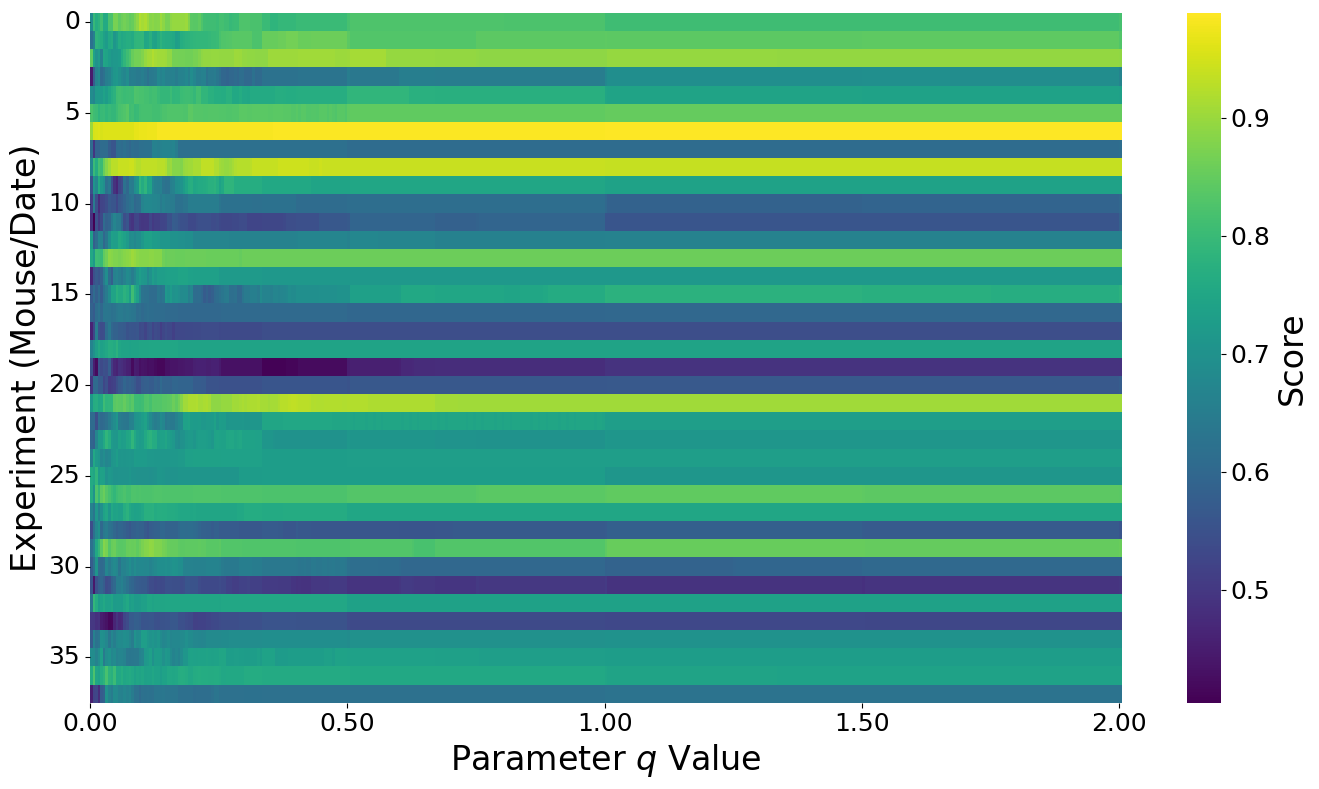

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = results.copy()

df['Experiment'] = df['Mouse'].astype(str) + "_" + df['Date'].astype(str)


heatmap_data = df.pivot(index='Experiment', columns='q', values='TDA Score')


plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})


fig, ax = plt.subplots(figsize=(14, 8))


sns.heatmap(heatmap_data, 
            cmap='viridis', 
            cbar_kws={'label': 'Score'},
            ax=ax)


ax.set_ylabel("Experiment (Mouse/Date)")
ax.set_xlabel("Parameter $q$ Value")


n_cols = len(heatmap_data.columns)
x_tick_positions = np.linspace(0, n_cols - 1, 5, dtype=int)
x_tick_labels = [f"{heatmap_data.columns[i]:.2f}" for i in x_tick_positions]

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0) 


n_rows = len(heatmap_data.index)
y_tick_positions = np.arange(0, n_rows, 5) 

ax.set_yticks(y_tick_positions + 0.5) 
ax.set_yticklabels(y_tick_positions, rotation=0)

plt.tight_layout()
plt.savefig('q_parameter_heatmap.pdf', bbox_inches='tight')
plt.show()